In [1]:
# Install the Kaggle library
!pip install kaggle

To download datasets from Kaggle, you need to set up your Kaggle API credentials. Follow these steps:

1.  Go to your Kaggle account page (kaggle.com/your-username/account).
2.  Under the 'API' section, click on 'Create New API Token'. This will download a `kaggle.json` file.
3.  Upload this `kaggle.json` file to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar, then clicking 'Upload to session storage'.
4.  Run the following cell to move the `kaggle.json` file to the correct directory and set its permissions.

In [2]:
# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle
# Move kaggle.json to the correct directory
!mv kaggle.json ~/.kaggle/
# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
!kaggle datasets files redwankarimsony/heart-disease-data

name                    size  creationDate                
---------------------  -----  --------------------------  
heart_disease_uci.csv  79346  2020-09-23 03:34:12.236000  


In [7]:
!kaggle datasets download redwankarimsony/heart-disease-data

Dataset URL: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
License(s): copyright-authors
100% 12.4k/12.4k [00:00<00:00, 35.5MB/s]



In [8]:
!unzip /content/heart-disease-data.zip -d /content/

Archive:  /content/heart-disease-data.zip
  inflating: /content/heart_disease_uci.csv  


In [9]:
import pandas as pd
df = pd.read_csv('/content/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


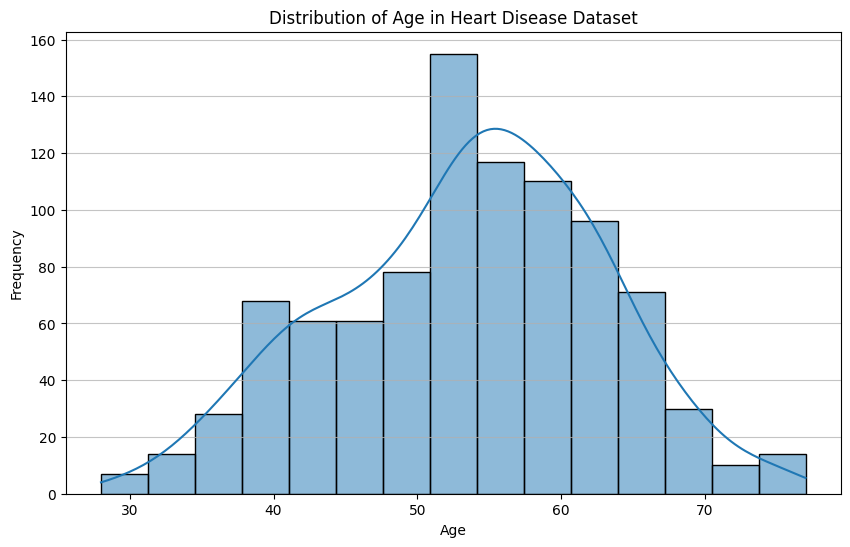

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a distribution plot for the 'age' column
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, bins=15)
plt.title('Distribution of Age in Heart Disease Dataset')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

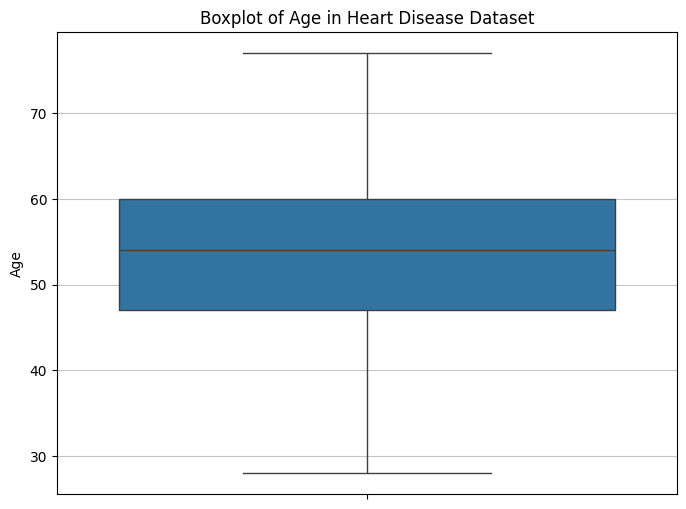

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for 'age'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['age'])
plt.title('Boxplot of Age in Heart Disease Dataset')
plt.ylabel('Age')
plt.grid(axis='y', alpha=0.75)
plt.show()


### Observation: Age Distribution (Boxplot)

This boxplot provides a summary of the age distribution, showing the median, quartiles, and potential outliers. It complements the histogram by clearly indicating the spread and central tendency.


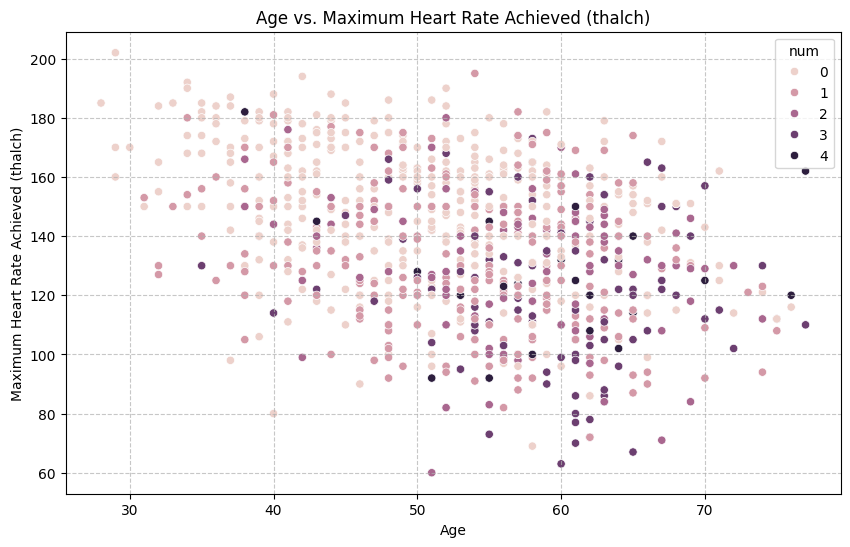

In [13]:
# Scatter plot of 'age' vs 'thalch'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['age'], y=df['thalch'], hue=df['num'])
plt.title('Age vs. Maximum Heart Rate Achieved (thalch)')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate Achieved (thalch)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### Observation: Age vs. Maximum Heart Rate Achieved

This scatter plot visualizes the relationship between a patient's age and their maximum heart rate achieved. The `hue` parameter shows the target variable `num` to see if there's any pattern related to heart disease presence. It helps us observe if certain age groups tend to have higher or lower max heart rates, and how this relates to the heart disease outcome.


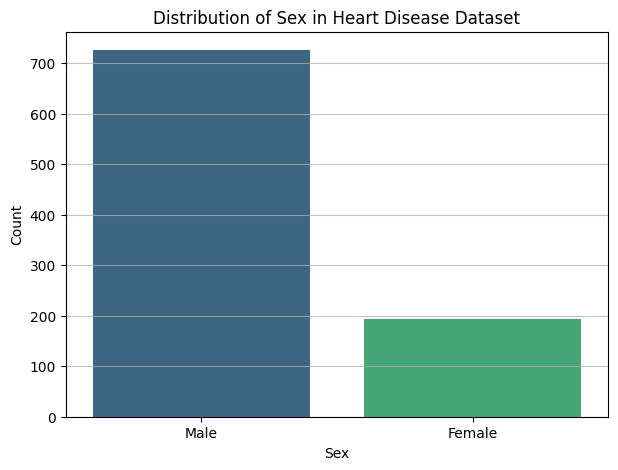

In [15]:
# Count plot for 'sex'
plt.figure(figsize=(7, 5))
sns.countplot(x=df['sex'], palette='viridis', hue=df['sex'], legend=False)
plt.title('Distribution of Sex in Heart Disease Dataset')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

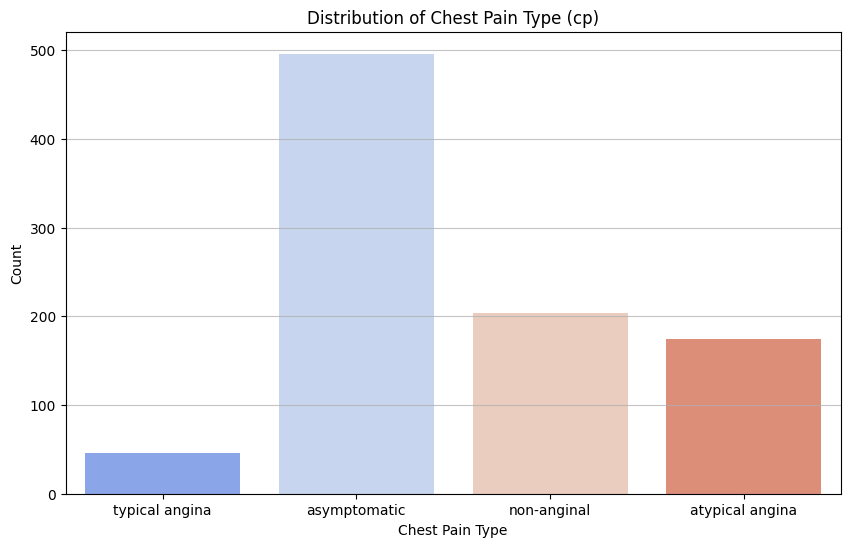

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['cp'], palette='coolwarm', hue=df['cp'], legend=False)
plt.title('Distribution of Chest Pain Type (cp)')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of Chest Pain Type

This count plot displays the frequency of each chest pain type (typical angina, atypical angina, non-anginal pain, and asymptomatic). It helps us understand which types of chest pain are most common in the dataset.

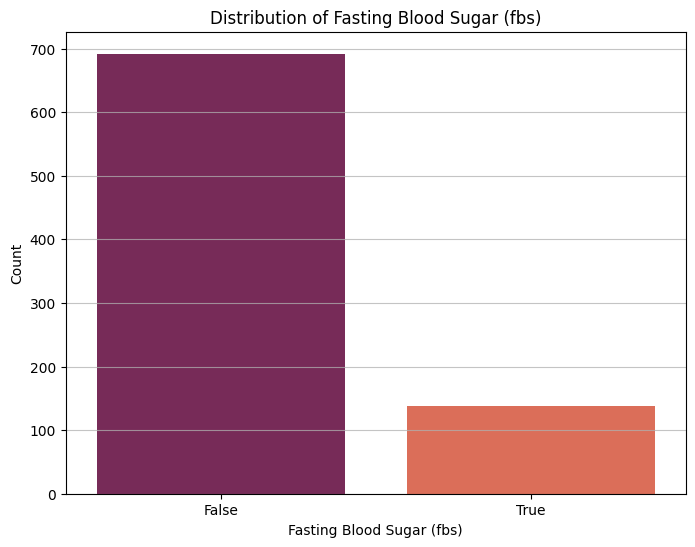

In [17]:
plt.figure(figsize=(8, 6))
sns.countplot(x=df['fbs'], palette='rocket', hue=df['fbs'], legend=False)
plt.title('Distribution of Fasting Blood Sugar (fbs)')
plt.xlabel('Fasting Blood Sugar (fbs)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of Fasting Blood Sugar (fbs)

This count plot illustrates the distribution of fasting blood sugar levels. It helps to see the proportion of patients with `fbs > 120 mg/dl` (True) versus `fbs <= 120 mg/dl` (False).

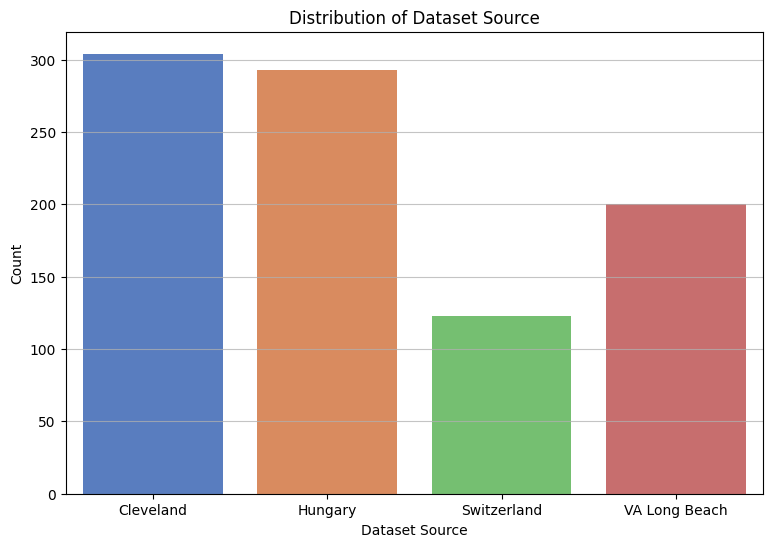

In [20]:
plt.figure(figsize=(9, 6))
sns.countplot(x=df['dataset'], palette='muted', hue=df['dataset'], legend=False)
plt.title('Distribution of Dataset Source')
plt.xlabel('Dataset Source')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of Dataset Source

This count plot displays the distribution of data points across different datasets. It shows which specific heart disease datasets contribute the most records to the combined DataFrame, providing insight into the data's origin and potential biases.

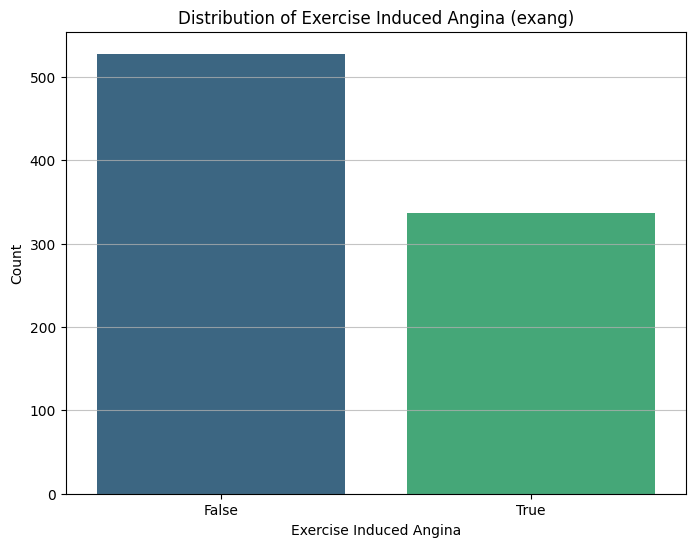

In [19]:
plt.figure(figsize=(8, 6))
sns.countplot(x=df['exang'], palette='viridis', hue=df['exang'], legend=False)
plt.title('Distribution of Exercise Induced Angina (exang)')
plt.xlabel('Exercise Induced Angina')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of Exercise Induced Angina (exang)

This count plot illustrates the proportion of patients who experience exercise-induced angina versus those who do not. This is an important factor in diagnosing heart conditions.

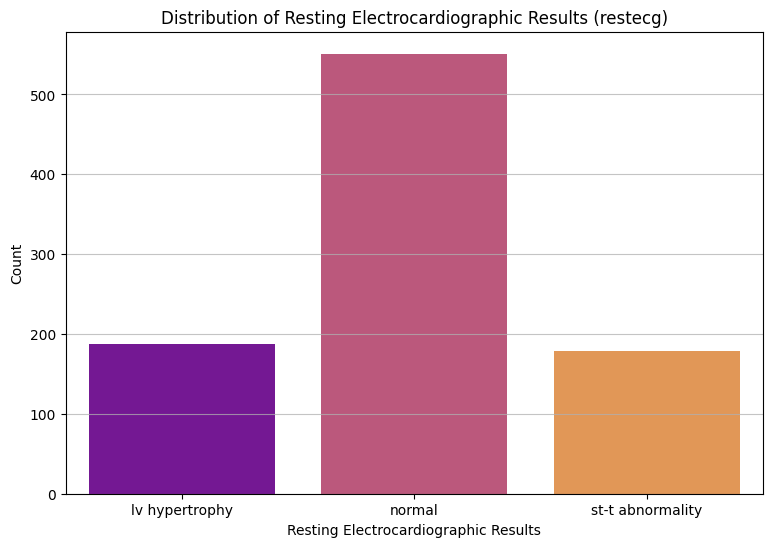

In [18]:
plt.figure(figsize=(9, 6))
sns.countplot(x=df['restecg'], palette='plasma', hue=df['restecg'], legend=False)
plt.title('Distribution of Resting Electrocardiographic Results (restecg)')
plt.xlabel('Resting Electrocardiographic Results')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of Resting Electrocardiographic Results (restecg)

This count plot shows the distribution of different resting electrocardiographic results. It provides insights into the prevalence of normal, ST-T wave abnormality, and left ventricular hypertrophy among the patients.

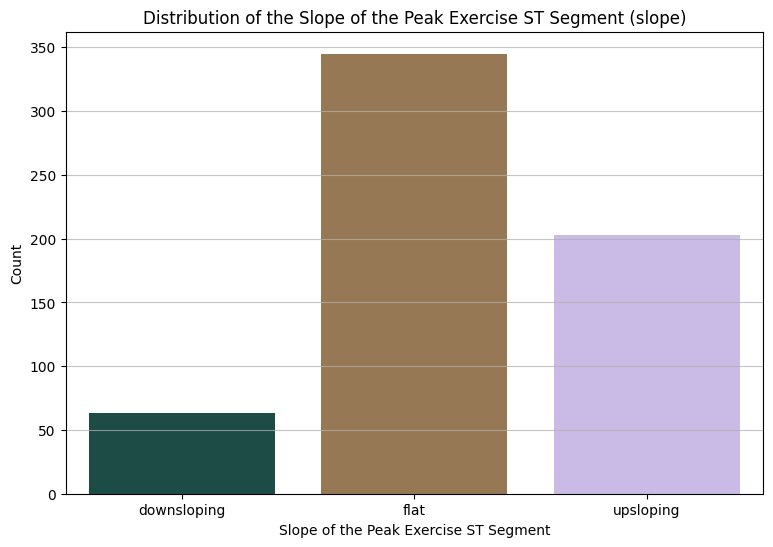

In [21]:
plt.figure(figsize=(9, 6))
sns.countplot(x=df['slope'], palette='cubehelix', hue=df['slope'], legend=False)
plt.title('Distribution of the Slope of the Peak Exercise ST Segment (slope)')
plt.xlabel('Slope of the Peak Exercise ST Segment')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of the Slope of the Peak Exercise ST Segment (slope)

This count plot shows the distribution of the 'slope' feature, which indicates the slope of the peak exercise ST segment. This information can be crucial in assessing heart health, with different slopes potentially pointing to varying degrees of cardiac issues.

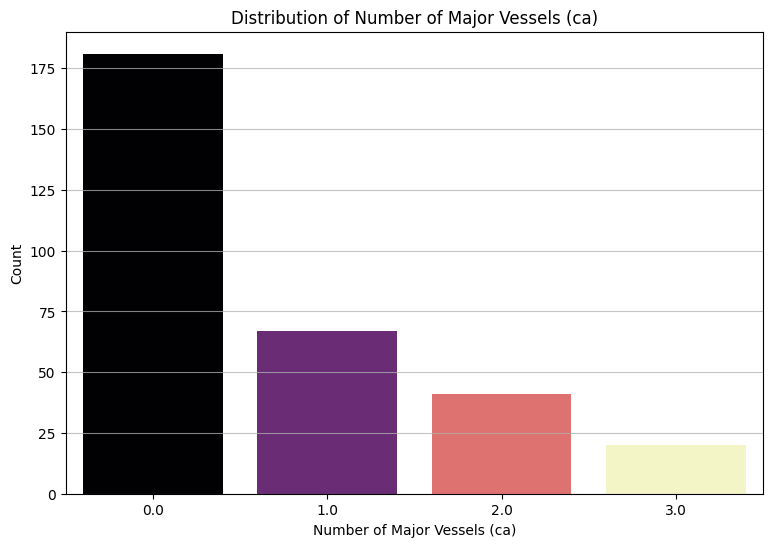

In [22]:
plt.figure(figsize=(9, 6))
sns.countplot(x=df['ca'], palette='magma', hue=df['ca'], legend=False)
plt.title('Distribution of Number of Major Vessels (ca)')
plt.xlabel('Number of Major Vessels (ca)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of Number of Major Vessels (ca)

This count plot shows the distribution of the 'ca' feature, indicating the number of major vessels (0-3) colored by flourosopy. This provides insight into the extent of coronary artery disease.

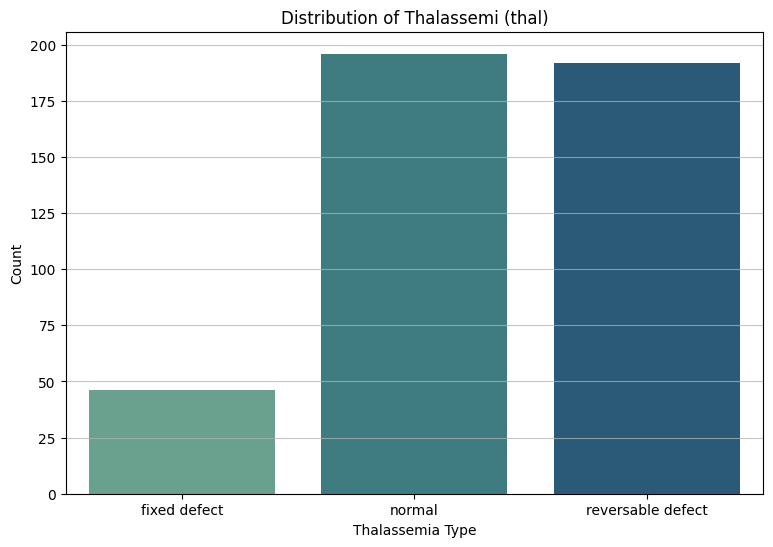

In [23]:
plt.figure(figsize=(9, 6))
sns.countplot(x=df['thal'], palette='crest', hue=df['thal'], legend=False)
plt.title('Distribution of Thalassemi (thal)')
plt.xlabel('Thalassemia Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Observation: Distribution of Thalassemia (thal)

This count plot displays the distribution of 'thalassemia' types, which is an inherited blood disorder. It shows the prevalence of normal, fixed defect, and reversable defect types among the patients.

### Observation: Distribution of Sex

This count plot shows the number of male and female participants in the dataset, providing insights into the gender balance of the study population.

In [11]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [25]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [26]:
print("--- Data Quality Checks ---")

# 1. Missing Values
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

--- Data Quality Checks ---

--- Missing Values ---
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


In [27]:
# 2. Duplicate Records
print("\n--- Duplicate Records ---")
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    print("Consider dropping duplicate rows if they represent exact identical entries.")


--- Duplicate Records ---
Number of duplicate rows: 0


In [31]:
# 3. Incorrect Data Types, Invalid Values, and Inconsistent Categories
print("\n--- Data Types and Unique Values Inspection ---")
print("Current Data Types:")
print(df.info())

# Inspect unique values for object type columns to find inconsistencies or invalid entries
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    print(f"\nUnique values for column '{col}':")
    print(df[col].unique())

print("\nChecking 'ca' column values (after potential NaN conversion):")
print(df['ca'].unique())
print("Checking 'thal' column values (after potential NaN conversion):")
print(df['thal'].unique())


--- Data Types and Unique Values Inspection ---
Current Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Unique values for column 'sex':
['Male' 'Female']

Uni

In [29]:
# 4. Outliers
print("\n--- Outliers (Numerical Columns) ---")
print("Descriptive statistics for numerical columns can help identify potential outliers:")
print(df.describe())
print("\nVisualizations like box plots (e.g., for 'trestbps', 'chol', 'thalch', 'oldpeak') can further aid in outlier detection.")


--- Outliers (Numerical Columns) ---
Descriptive statistics for numerical columns can help identify potential outliers:
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000   
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788   
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226   
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000   
25%    230.750000   47.000000  120.000000  175.000000  120.000000    0.000000   
50%    460.500000   54.000000  130.000000  223.000000  140.000000    0.500000   
75%    690.250000   60.000000  140.000000  268.000000  157.000000    1.500000   
max    920.000000   77.000000  200.000000  603.000000  202.000000    6.200000   

               ca         num  
count  309.000000  920.000000  
mean     0.676375    0.995652  
std      0.935653    1.142693  
min      0.000000    

### Outlier Detection using IQR Method

In [32]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("\n--- IQR-based Outlier Detection ---")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if not outliers.empty:
        print(f"\nColumn '{col}' has {len(outliers)} outliers:")
        display(outliers[[col]].head())
    else:
        print(f"\nColumn '{col}' has no outliers detected by IQR method.")



--- IQR-based Outlier Detection ---

Column 'id' has no outliers detected by IQR method.

Column 'age' has no outliers detected by IQR method.

Column 'trestbps' has 28 outliers:


,trestbps
14,172.0
83,180.0
126,200.0
172,174.0
183,178.0



Column 'chol' has 183 outliers:


,chol
48,417.0
152,564.0
181,409.0
373,412.0
434,468.0



Column 'thalch' has 2 outliers:


...


Column 'oldpeak' has 16 outliers:


,oldpeak
91,6.2
121,4.0
123,5.6
126,4.0
183,4.2



Column 'ca' has 20 outliers:


,ca
1,3.0
40,3.0
62,3.0
91,3.0
92,3.0



Column 'num' has no outliers detected by IQR method.


### Handling Invalid `trestbps` Values and Imputing Missing Data

I will replace the `0` values in `trestbps` with `NaN` as a `trestbps` of 0 is physiologically impossible and likely indicates missing data. Afterwards, I will impute all missing numerical values using the median. Median imputation is generally preferred over mean imputation when outliers are present, as the median is less sensitive to extreme values.

In [33]:
# Replace 0s in 'trestbps' with NaN
df['trestbps'] = df['trestbps'].replace(0, float('nan'))

# Impute missing numerical values with the median
numerical_cols_with_missing = df.select_dtypes(include=['float64', 'int64']).columns[df.select_dtypes(include=['float64', 'int64']).isnull().any()].tolist()

for col in numerical_cols_with_missing:
    if col != 'id': # 'id' is an identifier and should not be imputed
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after imputation:
fbs         90
restecg      2
exang       55
slope      309
thal       486
dtype: int64


### Outlier Capping using IQR Method

Based on the previous IQR outlier detection, we identified outliers in `trestbps`, `chol`, `thalch`, and `oldpeak`. To mitigate the impact of these extreme values without removing them entirely, we will apply a capping strategy. This involves replacing values beyond the lower and upper bounds with the respective bound values.

In [34]:
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    print(f"Outliers in '{col}' capped.")

print("\nDescriptive statistics after handling invalid values, imputation, and capping outliers:")
display(df.describe())

Outliers in 'trestbps' capped.
Outliers in 'chol' capped.
Outliers in 'thalch' capped.
Outliers in 'oldpeak' capped.

Descriptive statistics after handling invalid values, imputation, and capping outliers:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,460.500000,53.510870,131.768478,207.095516,137.702174,0.843696,0.227174,0.995652
std,265.725422,9.424685,16.865843,91.530131,25.116321,1.022640,0.628936,1.142693
min,1.000000,28.000000,90.000000,43.875000,66.000000,-2.250000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,267.000000,156.000000,1.500000,0.000000,2.000000
max,920.000000,77.000000,170.000000,400.875000,202.000000,3.750000,3.000000,4.000000


### Imputing Missing Categorical Values

After handling numerical missing values and outliers, we still have missing data in several categorical columns: `fbs`, `restecg`, `exang`, `slope`, and `thal`. For categorical features, a common imputation strategy is to replace missing values with the mode (most frequent category) of that column. This helps retain the most representative category while filling in the gaps.

In [35]:
# Impute missing categorical values with the mode
categorical_cols_with_missing = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

for col in categorical_cols_with_missing:
    mode_val = df[col].mode()[0] # .mode() returns a Series, so take the first element
    df[col] = df[col].fillna(mode_val)

print("Missing values after categorical imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nData types after all imputation steps:")
df.info()

Missing values after categorical imputation:
Series([], dtype: int64)

Data types after all imputation steps:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    object 
 13  ca        920 non-null    float64
 14  thal      920 non-null    object 
 15  num       920 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 102.6+ KB


/tmp/ipykernel_1062/677260868.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


## Feature Engineering

Feature engineering is a critical step in preparing data for machine learning models. It involves creating new features or transforming existing ones to improve model performance and interpretability. We will cover:

1.  **Encoding Categorical Features:** Converting non-numeric (object type) categorical variables into a numerical format that machine learning algorithms can understand.
2.  **Target Variable Transformation:** Modifying the `num` (heart disease presence) column into a binary target (0 or 1) suitable for binary classification.
3.  **Feature Scaling:** Standardizing the range of independent numerical features. This is important for many machine learning estimators that calculate distances between data points or use regularization.
4.  **Feature Creation:** Generating new features by combining or transforming existing ones to potentially uncover more predictive patterns.

### 1. Encoding Categorical Features

Many machine learning algorithms cannot directly work with categorical data (text labels). We need to convert these categories into numerical representations. For nominal categorical features (where there's no inherent order), **One-Hot Encoding** is a common and effective technique. It creates new binary columns for each category, indicating the presence or absence of that category.

In [36]:
# Identify categorical columns to be one-hot encoded (excluding 'id' and 'num')
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Categorical columns to encode: {categorical_cols}")

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("\nDataFrame head after one-hot encoding:")
display(df_encoded.head())
print(f"\nShape of DataFrame after encoding: {df_encoded.shape}")

Categorical columns to encode: ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']

DataFrame head after one-hot encoding:


,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,num,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1,63,145.0,233.0,True,150.0,False,2.3,0.0,0,...,0,0,0,1,0,0,0,0,0,0
1,2,67,160.0,286.0,False,108.0,True,1.5,3.0,2,...,0,0,0,0,0,0,1,0,1,0
2,3,67,120.0,229.0,False,129.0,True,2.6,2.0,1,...,0,0,0,0,0,0,1,0,0,1
3,4,37,130.0,250.0,False,187.0,False,3.5,0.0,0,...,0,0,1,0,1,0,0,0,1,0
4,5,41,130.0,204.0,False,172.0,False,1.4,0.0,0,...,0,1,0,0,0,0,0,1,1,0



Shape of DataFrame after encoding: (920, 23)


### 2. Target Variable Transformation

The `num` column indicates the presence of heart disease, with values ranging from 0 (no disease) to 4 (various stages of disease). For a common binary classification task, we want to predict simply whether heart disease is present or not. Therefore, we will transform `num` into a new binary target variable, where 0 means no heart disease and 1 means heart disease is present (any value > 0).

In [37]:
# Transform 'num' into a binary target variable
df_encoded['heart_disease_present'] = (df_encoded['num'] > 0).astype(int)

# Drop the original 'num' column as it's no longer needed
df_encoded = df_encoded.drop(columns=['num'])

print("Value counts for the new binary target variable 'heart_disease_present':")
display(df_encoded['heart_disease_present'].value_counts())

Value counts for the new binary target variable 'heart_disease_present':


,count
heart_disease_present,
1,509
0,411


### 3. Feature Scaling

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. Features with larger values might exert undue influence on the model simply due to their magnitude. **Standardization (Z-score normalization)** scales features to have a mean of 0 and a standard deviation of 1. This is particularly important for algorithms like Support Vector Machines, K-Nearest Neighbors, and neural networks.

In [38]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (exclude 'id' and the new target column)
numerical_cols_to_scale = df_encoded.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Remove 'id' and 'heart_disease_present' from the list of columns to scale
if 'id' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('id')
if 'heart_disease_present' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('heart_disease_present')

print(f"Numerical columns to scale: {numerical_cols_to_scale}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the identified numerical columns
df_encoded[numerical_cols_to_scale] = scaler.fit_transform(df_encoded[numerical_cols_to_scale])

print("\nDataFrame head after feature scaling (numerical columns):")
display(df_encoded.head())
print("\nDescriptive statistics of scaled numerical features:")
display(df_encoded[numerical_cols_to_scale].describe())

Numerical columns to scale: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']

DataFrame head after feature scaling (numerical columns):


,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,...,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,heart_disease_present
0,1,1.007386,0.784943,0.283170,True,0.489901,False,1.424838,-0.361400,0.516931,...,-0.482953,-0.533775,4.358899,-1.227523,-0.491493,-1.568007,-0.532094,-1.692792,-0.513553,0
1,2,1.432034,1.674798,0.862529,False,-1.183228,True,0.642124,4.411152,0.516931,...,-0.482953,-0.533775,-0.229416,-1.227523,-0.491493,0.637752,-0.532094,0.590740,-0.513553,1
2,3,1.432034,-0.698149,0.239445,False,-0.346663,True,1.718356,2.820301,0.516931,...,-0.482953,-0.533775,-0.229416,-1.227523,-0.491493,0.637752,-0.532094,-1.692792,1.947220,1
3,4,-1.752828,-0.104913,0.469002,False,1.963848,False,2.598910,-0.361400,0.516931,...,-0.482953,1.873447,-0.229416,0.814649,-0.491493,-1.568007,-0.532094,0.590740,-0.513553,0
4,5,-1.328180,-0.104913,-0.033838,False,1.366302,False,0.544284,-0.361400,-1.934494,...,2.070593,-0.533775,-0.229416,-1.227523,-0.491493,-1.568007,1.879367,0.590740,-0.513553,0



Descriptive statistics of scaled numerical features:


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
count,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,920.000000,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02
mean,6.178632e-17,4.711207e-16,-3.089316e-17,-6.178632e-17,5.406303e-17,6.178632e-17,6.178632e-17,-6.178632e-17,-3.089316e-17,0.000000,1.544658e-17,-1.312959e-16,-1.312959e-16,-1.544658e-16,6.178632e-17,9.267949e-17,-7.723291e-17,-1.081261e-16,1.004028e-16
std,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00
min,-2.708286e+00,-2.477860e+00,-1.784213e+00,-2.856357e+00,-3.026850e+00,-3.613997e-01,-1.934494e+00,-6.835968e-01,-3.928470e-01,-0.527046,-4.829534e-01,-5.337754e-01,-2.294157e-01,-1.227523e+00,-4.914931e-01,-1.568007e+00,-5.320941e-01,-1.692792e+00,-5.135526e-01
25%,-6.912073e-01,-6.981495e-01,-3.207848e-01,-7.051910e-01,-8.254660e-01,-3.613997e-01,5.169310e-01,-6.835968e-01,-3.928470e-01,-0.527046,-4.829534e-01,-5.337754e-01,-2.294157e-01,-1.227523e+00,-4.914931e-01,-1.568007e+00,-5.320941e-01,-1.692792e+00,-5.135526e-01
50%,5.192709e-02,-1.049126e-01,1.738568e-01,9.153713e-02,-3.362694e-01,-3.613997e-01,5.169310e-01,-6.835968e-01,-3.928470e-01,-0.527046,-4.829534e-01,-5.337754e-01,-2.294157e-01,8.146489e-01,-4.914931e-01,6.377522e-01,-5.320941e-01,5.907399e-01,-5.135526e-01
75%,6.888994e-01,4.883242e-01,6.548343e-01,7.289196e-01,6.421236e-01,-3.613997e-01,5.169310e-01,1.462851e+00,-3.928470e-01,-0.527046,-4.829534e-01,-5.337754e-01,-2.294157e-01,8.146489e-01,-4.914931e-01,6.377522e-01,-5.320941e-01,5.907399e-01,-5.135526e-01
max,2.493654e+00,2.268035e+00,2.118263e+00,2.561394e+00,2.843508e+00,4.411152e+00,5.169310e-01,1.462851e+00,2.545521e+00,1.897367,2.070593e+00,1.873447e+00,4.358899e+00,8.146489e-01,2.034617e+00,6.377522e-01,1.879367e+00,5.907399e-01,1.947220e+00


### 4. Feature Creation: Age Category

Creating new features can sometimes provide more meaningful information to a model than the raw features alone. For example, 'age' is a continuous variable, but often, age groups have different medical implications. Let's create an `age_category` feature by binning the `age` column into distinct groups (e.g., 'Young Adult', 'Middle-Aged', 'Senior'). This new categorical feature can capture non-linear relationships that a linear model might miss with just the continuous 'age' feature.

In [39]:
# Define age bins and labels
age_bins = [0, 40, 55, 100]  # Example bins: <40, 40-54, 55+
age_labels = ['Young Adult', 'Middle-Aged', 'Senior']

# Create the 'age_category' feature
df_encoded['age_category'] = pd.cut(df_encoded['age'], bins=age_bins, labels=age_labels, right=False)

print("Value counts for the new 'age_category' feature:")
display(df_encoded['age_category'].value_counts())

# We should now one-hot encode this newly created categorical feature
# Or, if we want to retain the 'age' numeric column, we can do that.
# For now, let's keep both, as it can sometimes be beneficial.
# If we decide to drop the original 'age' later, we can do so.

# Re-apply one-hot encoding if 'age_category' is to be used as discrete features
df_final = pd.get_dummies(df_encoded, columns=['age_category'], drop_first=True, dtype=int)

print("\nDataFrame head after adding and encoding 'age_category':")
display(df_final.head())
print(f"\nShape of final DataFrame after feature creation and re-encoding: {df_final.shape}")

Value counts for the new 'age_category' feature:


,count
age_category,
Young Adult,499
Middle-Aged,0
Senior,0



DataFrame head after adding and encoding 'age_category':


,id,age,trestbps,chol,fbs,thalch,exang,oldpeak,ca,sex_Male,...,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect,heart_disease_present,age_category_Middle-Aged,age_category_Senior
0,1,1.007386,0.784943,0.283170,True,0.489901,False,1.424838,-0.361400,0.516931,...,4.358899,-1.227523,-0.491493,-1.568007,-0.532094,-1.692792,-0.513553,0,0,0
1,2,1.432034,1.674798,0.862529,False,-1.183228,True,0.642124,4.411152,0.516931,...,-0.229416,-1.227523,-0.491493,0.637752,-0.532094,0.590740,-0.513553,1,0,0
2,3,1.432034,-0.698149,0.239445,False,-0.346663,True,1.718356,2.820301,0.516931,...,-0.229416,-1.227523,-0.491493,0.637752,-0.532094,-1.692792,1.947220,1,0,0
3,4,-1.752828,-0.104913,0.469002,False,1.963848,False,2.598910,-0.361400,0.516931,...,-0.229416,0.814649,-0.491493,-1.568007,-0.532094,0.590740,-0.513553,0,0,0
4,5,-1.328180,-0.104913,-0.033838,False,1.366302,False,0.544284,-0.361400,-1.934494,...,-0.229416,-1.227523,-0.491493,-1.568007,1.879367,0.590740,-0.513553,0,0,0



Shape of final DataFrame after feature creation and re-encoding: (920, 25)


In [47]:
import pandas as pd
import numpy as np

# Calculate correlations with the target variable 'heart_disease_present'
# Exclude 'id' as it's just an identifier
X_corr_features = df_final.drop(columns=['id', 'heart_disease_present'], errors='ignore')
y_corr = df_final['heart_disease_present']

correlations_with_target = X_corr_features.corrwith(y_corr)

print("Correlation of features with the target variable 'heart_disease_present':\n")
display(correlations_with_target.sort_values(ascending=False))

print("\nFeatures with absolute correlation greater than 0.25:")
strong_correlations = correlations_with_target[abs(correlations_with_target) > 0.25]
display(strong_correlations.sort_values(key=abs, ascending=False))

Correlation of features with the target variable 'heart_disease_present':



/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
exang,0.433605
oldpeak,0.371369
sex_Male,0.307284
dataset_Switzerland,0.301614
age,0.282700
thal_reversable defect,0.257029
dataset_VA Long Beach,0.203267
ca,0.164755
trestbps,0.109060
fbs,0.108071



Features with absolute correlation greater than 0.25:


,0
exang,0.433605
cp_atypical angina,-0.403465
thalch,-0.381953
oldpeak,0.371369
sex_Male,0.307284
dataset_Switzerland,0.301614
thal_normal,-0.286196
age,0.282700
dataset_Hungary,-0.263297
thal_reversable defect,0.257029


### Update Dataset with Selected Features

Based on the correlation analysis, we will now create a new DataFrame containing only the features that showed a strong absolute correlation (greater than 0.25) with the target variable, plus the target variable itself. This pruned dataset will be used for further analysis or model training.

In [46]:
# Get the names of the strongly correlated features
selected_feature_names = strong_correlations.index.tolist()

# Add the target variable to the list of selected features
selected_feature_names.append('heart_disease_present')

# Create a new DataFrame with only the selected features and the target
df_selected = df_final[selected_feature_names].copy()

print("Shape of the new DataFrame with selected features:", df_selected.shape)
print("First 5 rows of the selected DataFrame:")
display(df_selected.head())

Shape of the new DataFrame with selected features: (920, 11)
First 5 rows of the selected DataFrame:


,age,thalch,exang,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,cp_atypical angina,thal_normal,thal_reversable defect,heart_disease_present
0,1.007386,0.489901,False,1.424838,0.516931,-0.683597,-0.392847,-0.482953,-1.692792,-0.513553,0
1,1.432034,-1.183228,True,0.642124,0.516931,-0.683597,-0.392847,-0.482953,0.590740,-0.513553,1
2,1.432034,-0.346663,True,1.718356,0.516931,-0.683597,-0.392847,-0.482953,-1.692792,1.947220,1
3,-1.752828,1.963848,False,2.598910,0.516931,-0.683597,-0.392847,-0.482953,0.590740,-0.513553,0
4,-1.328180,1.366302,False,0.544284,-1.934494,-0.683597,-0.392847,2.070593,0.590740,-0.513553,0


## Train-Test Split and Model Training (Logistic Regression Baseline Model)

In this section, we will prepare our `df_selected` dataset for machine learning by splitting it into training and testing sets. We will then train a Logistic Regression model as a baseline and evaluate its performance.

1.  **Splitting Data**: Divide the data into features (X) and target (y), then further split them into training and testing sets.
2.  **Model Training**: Initialize and train a `LogisticRegression` model on the training data.
3.  **Prediction**: Make predictions on the test set.
4.  **Evaluation**: Assess the model's performance using relevant metrics.

### 1. Splitting Data into Training and Testing Sets

We'll use `sklearn.model_selection.train_test_split` to divide our `df_selected` DataFrame into training and testing sets. This is a crucial step to evaluate how well our model generalizes to unseen data.

In [48]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) from df_selected
# The 'id' column was already excluded in the feature selection step.
X = df_selected.drop(columns=['heart_disease_present'])
y = df_selected['heart_disease_present']

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

X_train shape: (736, 10)
X_test shape: (184, 10)
y_train shape: (736,)
y_test shape: (184,)

First 5 rows of X_train:


,age,thalch,exang,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,cp_atypical angina,thal_normal,thal_reversable defect
640,-0.054235,-0.625518,True,-0.825466,0.516931,-0.683597,2.545521,-0.482953,-1.692792,1.947220
743,2.175168,0.091537,False,-0.336269,0.516931,-0.683597,-0.392847,-0.482953,0.590740,-0.513553
890,-0.054235,-0.625518,True,1.131320,0.516931,-0.683597,-0.392847,-0.482953,-1.692792,1.947220
270,0.795061,0.011864,True,1.033481,0.516931,-0.683597,-0.392847,-0.482953,-1.692792,1.947220
654,0.264251,-1.541755,False,-0.825466,0.516931,-0.683597,2.545521,-0.482953,0.590740,-0.513553


### 2. Model Training: Logistic Regression Baseline

Logistic Regression is a simple yet effective linear model for binary classification. It serves as a good baseline to compare more complex models against. We'll train it on our `X_train` and `y_train` data.

In [49]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set max_iter for convergence and random_state for reproducibility
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print(f"Model coefficients: {log_reg_model.coef_[0]}")
print(f"Model intercept: {log_reg_model.intercept_[0]}")

Logistic Regression model trained successfully.
Model coefficients: [ 0.33320452 -0.3730911   1.19787732  0.57464781  0.53212355 -0.04655996
  0.79332935 -0.5520652  -0.24914167  0.09694017]
Model intercept: -0.04901479017754679


### 3. Prediction

After training, we use the model to make predictions on the `X_test` dataset. These predictions will then be compared against the actual `y_test` values to evaluate the model's performance.

In [50]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1] # Probability of the positive class

print("First 10 predictions (binary):")
display(y_pred[:10])
print("First 10 prediction probabilities (positive class):")
display(y_pred_proba[:10])

First 10 predictions (binary):


array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1])

First 10 prediction probabilities (positive class):


array([0.23183135, 0.97638058, 0.84294654, 0.96158155, 0.58331743,
       0.8401006 , 0.48602534, 0.93675782, 0.13351379, 0.76371563])

### 4. Model Evaluation

We will evaluate the performance of our Logistic Regression baseline model using several metrics common for binary classification:

*   **Accuracy Score**: The proportion of correctly classified instances.
*   **Precision**: The proportion of positive identifications that were actually correct.
*   **Recall**: The proportion of actual positives that were identified correctly.
*   **F1-Score**: The harmonic mean of precision and recall.
*   **Confusion Matrix**: A table showing the number of true positives, true negatives, false positives, and false negatives.
*   **ROC AUC Score**: The Area Under the Receiver Operating Characteristic curve, which measures the model's ability to distinguish between classes.

Accuracy: 0.8370
Precision: 0.8273
Recall: 0.8922
F1-Score: 0.8585
ROC AUC Score: 0.9014


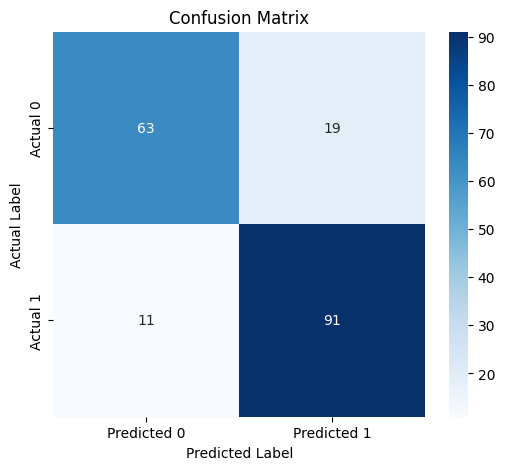

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## Random Forest Model

Now, let's explore a more complex model, the Random Forest Classifier, to see if we can achieve better performance than our Logistic Regression baseline. Random Forests are ensemble learning methods that build multiple decision trees and merge their predictions to get a more accurate and stable prediction.

We will follow similar steps as with the Logistic Regression model:

1.  **Model Training**: Initialize and train a `RandomForestClassifier` on the training data.
2.  **Prediction**: Make predictions on the test set.
3.  **Evaluation**: Assess the model's performance using the same metrics as before.
4.  **Comparison**: Compare the results with the Logistic Regression baseline.

### 1. Model Training: RandomForestClassifier

We'll initialize a `RandomForestClassifier` and train it on our `X_train` and `y_train` data. For simplicity, we'll start with default parameters, but these could be tuned for better performance later.

In [52]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# Set random_state for reproducibility
rf_model = RandomForestClassifier(random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 2. Prediction

Now, we'll use the trained Random Forest model to make predictions on the `X_test` dataset. This will provide the predicted classes and probabilities for the positive class.

In [53]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Probability of the positive class

print("First 10 predictions (binary) from Random Forest:")
display(y_pred_rf[:10])
print("First 10 prediction probabilities (positive class) from Random Forest:")
display(y_pred_proba_rf[:10])

First 10 predictions (binary) from Random Forest:


array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1])

First 10 prediction probabilities (positive class) from Random Forest:


array([0.43      , 0.91      , 0.82666667, 0.98      , 0.91      ,
       0.97      , 0.14      , 0.97      , 0.01      , 0.76      ])

### 3. Model Evaluation

We will evaluate the performance of the Random Forest model using the same set of metrics: Accuracy, Precision, Recall, F1-Score, ROC AUC Score, and a Confusion Matrix.

Random Forest Accuracy: 0.8098
Random Forest Precision: 0.8190
Random Forest Recall: 0.8431
Random Forest F1-Score: 0.8309
Random Forest ROC AUC Score: 0.8833


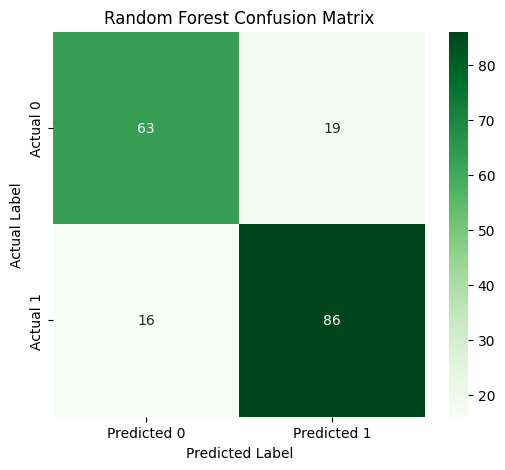

In [54]:
# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print(f"Random Forest F1-Score: {f1_rf:.4f}")
print(f"Random Forest ROC AUC Score: {roc_auc_rf:.4f}")

# Plot Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 4. Comparison with Logistic Regression Baseline

Let's compare the key performance metrics of the Random Forest model with our Logistic Regression baseline to see if it offers an improvement.

In [55]:
print("--- Model Performance Comparison ---")
print("Logistic Regression:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  ROC AUC Score: {roc_auc:.4f}")

print("\nRandom Forest:")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")
print(f"  ROC AUC Score: {roc_auc_rf:.4f}")

# You can also add a visual comparison, e.g., a bar chart of metrics

--- Model Performance Comparison ---
Logistic Regression:
  Accuracy: 0.8370
  Precision: 0.8273
  Recall: 0.8922
  F1-Score: 0.8585
  ROC AUC Score: 0.9014

Random Forest:
  Accuracy: 0.8098
  Precision: 0.8190
  Recall: 0.8431
  F1-Score: 0.8309
  ROC AUC Score: 0.8833


## Hyperparameter Tuning for Random Forest using GridSearchCV

To potentially improve the performance of our Random Forest model, we will perform hyperparameter tuning using `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which combination gives the best performance.

### 1. Define Parameter Grid

We will define a dictionary `param_grid` specifying the hyperparameters to tune and the values to test for each. Common hyperparameters for `RandomForestClassifier` include:

*   `n_estimators`: The number of trees in the forest.
*   `max_features`: The number of features to consider when looking for the best split.
*   `max_depth`: The maximum depth of the tree.
*   `min_samples_split`: The minimum number of samples required to split an internal node.
*   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.

In [56]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 150], # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

print("Random Forest Parameter Grid:")
print(param_grid)

Random Forest Parameter Grid:
{'n_estimators': [50, 100, 150], 'max_features': ['sqrt', 'log2'], 'max_depth': [10, 20, 30, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}


### 2. Initialize and Fit GridSearchCV

We'll create a `GridSearchCV` object, passing our `RandomForestClassifier`, the `param_grid`, and cross-validation settings (e.g., `cv=5` for 5-fold cross-validation). Then, we'll fit it to our training data.

In [57]:
# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           verbose=2, # Display progress
                           scoring='roc_auc') # Optimize for ROC AUC score

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
GridSearchCV completed.


### 3. Best Parameters and Best Score

After fitting, `GridSearchCV` will have identified the best combination of hyperparameters and the corresponding best performance score.

In [58]:
# Get the best parameters
best_params_rf = grid_search.best_params_
print(f"Best parameters for Random Forest: {best_params_rf}")

# Get the best score
best_score_rf = grid_search.best_score_
print(f"Best ROC AUC score (from cross-validation): {best_score_rf:.4f}")

Best parameters for Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Best ROC AUC score (from cross-validation): 0.8644


### 4. Evaluate Tuned Random Forest Model

Now, we will train a new Random Forest model using the `best_params_rf` found by `GridSearchCV` and evaluate its performance on the test set. We'll then compare these results with our previous models.

Tuned Random Forest Accuracy: 0.8315
Tuned Random Forest Precision: 0.8381
Tuned Random Forest Recall: 0.8627
Tuned Random Forest F1-Score: 0.8502
Tuned Random Forest ROC AUC Score: 0.9017


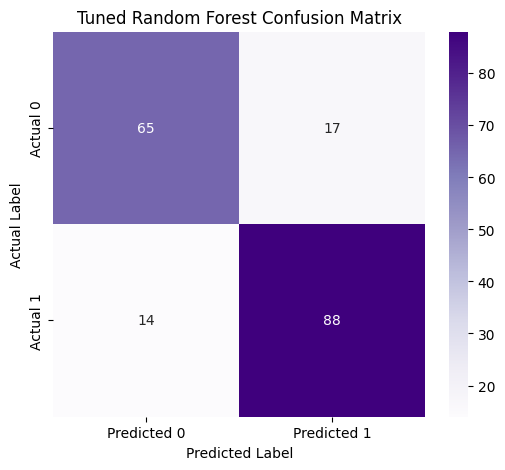

In [59]:
# Initialize Random Forest with the best parameters
rf_tuned_model = RandomForestClassifier(random_state=42, **best_params_rf)

# Train the tuned model on the training data
rf_tuned_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_tuned = rf_tuned_model.predict(X_test)
y_pred_proba_rf_tuned = rf_tuned_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for the tuned Random Forest
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_pred_rf_tuned)
recall_rf_tuned = recall_score(y_test, y_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_pred_rf_tuned)
roc_auc_rf_tuned = roc_auc_score(y_test, y_pred_proba_rf_tuned)

print(f"Tuned Random Forest Accuracy: {accuracy_rf_tuned:.4f}")
print(f"Tuned Random Forest Precision: {precision_rf_tuned:.4f}")
print(f"Tuned Random Forest Recall: {recall_rf_tuned:.4f}")
print(f"Tuned Random Forest F1-Score: {f1_rf_tuned:.4f}")
print(f"Tuned Random Forest ROC AUC Score: {roc_auc_rf_tuned:.4f}")

# Plot Confusion Matrix for Tuned Random Forest
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Tuned Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### 5. Final Model Performance Comparison

Let's compile and compare the performance metrics of the Logistic Regression, the default Random Forest, and the hyperparameter-tuned Random Forest models.

In [60]:
print("--- Final Model Performance Comparison ---")
print("Logistic Regression:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  ROC AUC Score: {roc_auc:.4f}")

print("\nDefault Random Forest:")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")
print(f"  ROC AUC Score: {roc_auc_rf:.4f}")

print("\nTuned Random Forest:")
print(f"  Accuracy: {accuracy_rf_tuned:.4f}")
print(f"  Precision: {precision_rf_tuned:.4f}")
print(f"  Recall: {recall_rf_tuned:.4f}")
print(f"  F1-Score: {f1_rf_tuned:.4f}")
print(f"  ROC AUC Score: {roc_auc_rf_tuned:.4f}")

--- Final Model Performance Comparison ---
Logistic Regression:
  Accuracy: 0.8370
  Precision: 0.8273
  Recall: 0.8922
  F1-Score: 0.8585
  ROC AUC Score: 0.9014

Default Random Forest:
  Accuracy: 0.8098
  Precision: 0.8190
  Recall: 0.8431
  F1-Score: 0.8309
  ROC AUC Score: 0.8833

Tuned Random Forest:
  Accuracy: 0.8315
  Precision: 0.8381
  Recall: 0.8627
  F1-Score: 0.8502
  ROC AUC Score: 0.9017


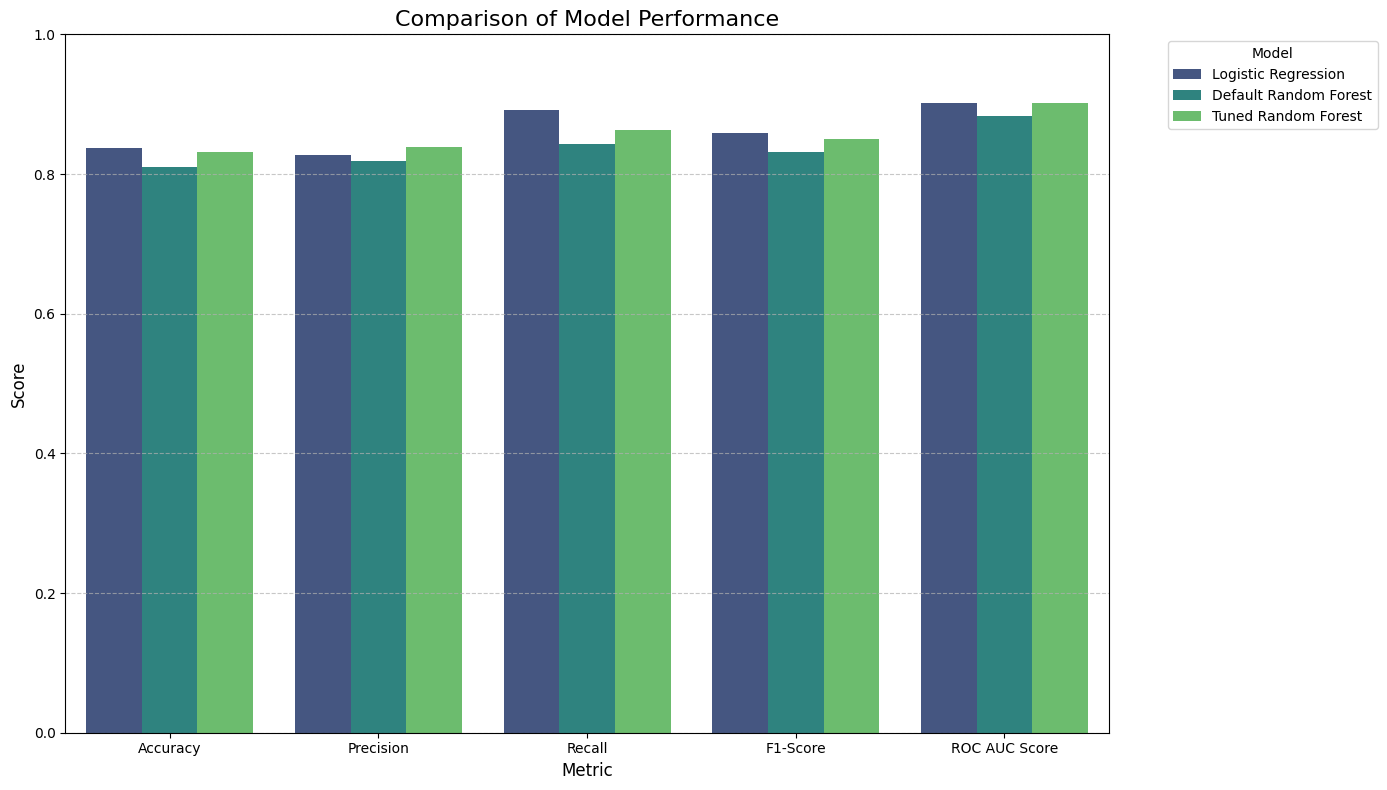

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a dictionary of model performances
performance_data = {
    'Model': ['Logistic Regression', 'Default Random Forest', 'Tuned Random Forest'],
    'Accuracy': [accuracy, accuracy_rf, accuracy_rf_tuned],
    'Precision': [precision, precision_rf, precision_rf_tuned],
    'Recall': [recall, recall_rf, recall_rf_tuned],
    'F1-Score': [f1, f1_rf, f1_rf_tuned],
    'ROC AUC Score': [roc_auc, roc_auc_rf, roc_auc_rf_tuned]
}

# Convert to DataFrame
performance_df = pd.DataFrame(performance_data)

# Melt the DataFrame for easy plotting with seaborn
performance_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 8))
sns.barplot(x='Metric', y='Score', hue='Model', data=performance_melted, palette='viridis')
plt.title('Comparison of Model Performance', fontsize=16)
plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.0, 1.0) # Scores are typically between 0 and 1
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [62]:
display(performance_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Logistic Regression,0.836957,0.827273,0.892157,0.858491,0.901363
1,Default Random Forest,0.809783,0.819048,0.843137,0.830918,0.883309
2,Tuned Random Forest,0.831522,0.838095,0.862745,0.850242,0.901722


In [63]:
def validate_data(df):
    print("Missing Values")
    print(df.isnull().sum())


    print("Duplicates")
    print(df.duplicated().sum())

validate_data(df)

Missing Values
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
Duplicates
0


In [64]:
def validate_data(df):
    assert df.isnull().sum().sum() == 0, "Missing values found!"
    assert df.duplicated().sum() == 0, "Duplicate rows found!"
    print("Validation Passed!")

validate_data(df)

Validation Passed!


In [66]:
import pandas as pd
import numpy as np

def validate_heart_dataset(df):
    results = []
    # Check 1: Missing values
    missing = df.isnull().sum()
    missing_cols = missing[missing > 0]
    results.append({"Check": "Missing Values",
                    "Status": "FAIL" if len(missing_cols)>0 else "PASS",
                    "Detail": str(missing_cols.to_dict())})
    # Check 2: Duplicate rows
    n_dup = df.duplicated().sum()
    results.append({"Check": "Duplicate Rows",
                    "Status": "FAIL" if n_dup>0 else "PASS",
                    "Detail": f"{n_dup} duplicate rows found"})
    # Check 3: Data types
    # Define expected data types for a subset of columns, as '...' is not valid Python syntax.
    # You would need to explicitly list all columns and their expected types.
    expected = {"age":"int64","sex":"object","cp":"object","trestbps":"float64","chol":"float64"}
    type_issues = {c: str(df[c].dtype) for c in expected
                   if c in df.columns and str(df[c].dtype) != expected[c]}
    results.append({"Check": "Data Types",
                    "Status": "WARN" if type_issues else "PASS",
                    "Detail": str(type_issues)})
    # Check 4: Value ranges
    # 'range_checks' is not defined. You would need to define it or pass it as an argument.
    # For demonstration, I'm defining a placeholder. Replace with actual checks.
    range_checks = {}
    # Example: range_checks = {"age": (0, 120), "trestbps": (50, 250)}
    range_issues = {}
    for col, (lo, hi) in range_checks.items():
        n_out = ((df[col]<lo)|(df[col]>hi)).sum()
        if n_out: range_issues[col] = n_out
    results.append({"Check": "Value Range",
                    "Status": "FAIL" if range_issues else "PASS",
                    "Detail": str(range_issues)})
    # Check 5: Outliers (IQR method)
    # 'outlier_counts' is not defined. Initializing it.
    outlier_counts = {}
    for col in [c for c in ["age","trestbps","chol","thalach","oldpeak"] if c in df.columns]:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        n_out = ((df[col]<Q1-1.5*IQR)|(df[col]>Q3+1.5*IQR)).sum()
        if n_out: outlier_counts[col] = n_out
    results.append({"Check": "Outliers (IQR)",
                    "Status": "FAIL" if outlier_counts else "PASS",
                    "Detail": str(outlier_counts)})
    return pd.DataFrame(results)